Data Preprocessing.

In [1]:
import pandas as pd

# Load data
df = pd.read_csv("../data/goldstandard_eng.csv")

In [2]:
df.head()

,GeneratedID,EntityNodeID,URL,HOST,s:name,s:description,s:brand,Properties,s:category,s:breadcrumb,GS1_Level1_Category,GS1_Level2_Category,GS1_Level3_Category
0,-1706714430,noded7a19a4737d9aaaa72d5c2b760568551,http://acc.teamfanshop.com/COLLEGE_North_Carol...,acc.teamfanshop.com,North Carolina Tar Heels (UNC) Womens Team Col...,NaN,NaN,http://schema.org/Product/offers\|http://schem...,North Carolina Tar Heels > North Carolina Tar ...,NaN,63000000_Footwear,63010000_Footwear,63010400_Indoor Footwear
1,214573103,noded5365e24e9b67399d547e93cdc8a137d,http://acc.teamfanshop.com/COLLEGE_Duke_Blue_D...,acc.teamfanshop.com,Duke Blue Devils Top of the World 2014 NCAA Me...,Celebrate the big victory alongside your Duke ...,Top of the World,http://schema.org/Product/offers\|http://schem...,Duke Blue Devils > Duke Blue Devils Hats,NaN,67000000_Clothing,67010000_Clothing,67010100_Clothing Accessories
2,607174015,node8c18878b813d89a8d7a389a4823a8179,http://acc.teamfanshop.com/on_sale/yes/browse/...,acc.teamfanshop.com,Mens Duke Blue Devils Nike Duke Blue Basketbal...,Celebrate your fandom with this Duke Blue Devi...,Nike,http://schema.org/Product/offers\|http://schem...,Yes > Sale Items,NaN,67000000_Clothing,67010000_Clothing,67010800_Upper Body Wear/Tops
3,-1706714430,noded7a19a4737d9aaaa72d5c2b760568551,http://'in'!acc.teamfanshop.com/COLLEGE_North_...,acc.teamfanshop.com,North Carolina Tar Heels (UNC) Womens Team Col...,NaN,NaN,http://schema.org/Product/offers\|http://schem...,North Carolina Tar Heels > North Carolina Tar ...,NaN,63000000_Footwear,63010000_Footwear,63010400_Indoor Footwear
4,-1081148535,node293a21132d32c202f499676b0295a2b,http://acc.teamfanshop.com/COLLEGE_Duke_Blue_D...,acc.teamfanshop.com,Youth Duke Blue Devils Royal Blue Blitz Footba...,Help him cheer on the Duke Blue Devils in this...,Colosseum,http://schema.org/Product/offers\|http://schem...,Duke Blue Devils > Duke Blue Devils Jerseys,NaN,67000000_Clothing,67010000_Clothing,67010800_Upper Body Wear/Tops


In [3]:
# Basic info
df.shape

(8358, 13)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8358 entries, 0 to 8357
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   GeneratedID          8358 non-null   object
 1   EntityNodeID         8354 non-null   object
 2   URL                  8354 non-null   object
 3   HOST                 8354 non-null   object
 4   s:name               8354 non-null   object
 5   s:description        7749 non-null   object
 6   s:brand              3607 non-null   object
 7   Properties           8354 non-null   object
 8   s:category           7176 non-null   object
 9   s:breadcrumb         1197 non-null   object
 10  GS1_Level1_Category  8354 non-null   object
 11  GS1_Level2_Category  8354 non-null   object
 12  GS1_Level3_Category  8354 non-null   object
dtypes: object(13)
memory usage: 849.0+ KB


In [5]:
df.describe()

,GeneratedID,EntityNodeID,URL,HOST,s:name,s:description,s:brand,Properties,s:category,s:breadcrumb,GS1_Level1_Category,GS1_Level2_Category,GS1_Level3_Category
count,8358,8354,8354,8354,8354,7749,3607,8354,7176,1197,8354,8354,8354
unique,8354,8353,5495,702,8046,7081,1028,262,3298,826,37,76,290
top,#NAME?,noded7a19a4737d9aaaa72d5c2b760568551,http://clemson.fanatics.com/COLLEGE_Clemson_Ti...,prostudio360.com,Royal Greens Ultra -,Get an understated winterwear look with this A...,Nike,http://schema.org/Product/offers\|http://schem...,Yes > Sale Items,Marketplace,67000000_Clothing,67010000_Clothing,67010800_Upper Body Wear/Tops
freq,4,2,20,25,7,31,425,2721,171,32,3948,3948,3006


In [6]:
df["Properties"].sample()
# df.sample()["Properties"].values

3800    http://schema.org/Product/offers\|http://schem...
Name: Properties, dtype: object

In [7]:
# Drop irrelevant or redundant columns
df.drop(columns=[
    "GeneratedID", "EntityNodeID", "URL", "HOST", 
    "s:breadcrumb", "Properties", "s:brand"
], errors='ignore', inplace=True)

In [8]:
# Handle duplicates
print("Duplicate rows:", df.duplicated().sum())
df.drop_duplicates(inplace=True)

Duplicate rows: 199


In [9]:
# Handle missing values
df_missing_cat = df[df["s:category"].isna()]
df_missing_cat.drop(columns=["GS1_Level1_Category", "GS1_Level2_Category", "GS1_Level3_Category"], inplace=True)
df.dropna(inplace=True)
df_missing_cat.head()

C:\Users\suraj\AppData\Local\Temp\ipykernel_3996\3738650551.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_missing_cat.drop(columns=["GS1_Level1_Category", "GS1_Level2_Category", "GS1_Level3_Category"], inplace=True)


,s:name,s:description,s:category
43,2005 Lincoln Town Car Sedan,"""The standard features of the Lincoln Town Car...",NaN
44,2015 Audi S6 Sedan,"""The standard features of the Audi S6 4.0T inc...",NaN
45,2004 Toyota Highlander SUV,"""The standard features of the Toyota Highlande...",NaN
46,2003 Suzuki Aerio Sedan,"""The standard features of the Suzuki Aerio S i...",NaN
47,2001 Volvo S80 Sedan,"""The standard features of the Volvo S80 2.9 in...",NaN


In [10]:
df[(df["s:category"].str.strip())==""]

,s:name,s:description,s:category,GS1_Level1_Category,GS1_Level2_Category,GS1_Level3_Category
386,347207-001 HP UPS R6000 UPS Systems,Description:UPS R6000 UPS Systems Option Part...,,65000000_Computing,65010000_Computers/Video Games,65010200_Computer Components
398,278535-B21 HP POWER SUPPLY 800W HOT PL,Description:Power Supply 800W Hot-Plug Option...,,65000000_Computing,65010000_Computers/Video Games,65010200_Computer Components
399,269021-B21 HP 36.4-GB Ultra320 SCSI,Description:36GB ULTRA320 SCSI 1 inCH Option...,,65000000_Computing,65010000_Computers/Video Games,65010300_Computer Drives
3325,HP 340745-003 20/40-GB DLT4000 SCSI SE,Description:20/40GB DLT4000 SCSI/SE StndAlone ...,,65000000_Computing,65010000_Computers/Video Games,65010200_Computer Components
3330,DC132D HP V.92 56K SoftModem,Description:V.92 56K International SoftModem A...,,65000000_Computing,65010000_Computers/Video Games,65010200_Computer Components
3336,Q1553A HP 20/40-GB DAT Internal,Description: (Hewlett-Packard) StorageWorks DA...,,65000000_Computing,65010000_Computers/Video Games,65010200_Computer Components
3742,400295-001 HP STORAGEWORKSRA 8000 HSX80,Description:StorageWorks RA 8000 HSX80 CACHE B...,,65000000_Computing,65010000_Computers/Video Games,65010200_Computer Components
4476,267555-B21 HP HPRPS DL560,Description:Hot-Plug Redundant Power Supply NE...,,65000000_Computing,65010000_Computers/Video Games,65010200_Computer Components
4478,246504-B21 HP 100-GBAIT Tape Media met,Description: 100GB AIT Tape Media met MIC (5 s...,,65000000_Computing,65010000_Computers/Video Games,65010200_Computer Components
4479,201202-001 HP DL580 2x1.4GHz 2GB,Description: Proliant DL580 G2 1.4GHz Xeon 512...,,65000000_Computing,65010000_Computers/Video Games,65010200_Computer Components


In [11]:
df[(df["s:description"].str.strip())==""]

,s:name,s:description,s:category,GS1_Level1_Category,GS1_Level2_Category,GS1_Level3_Category
6115,Konad Set B (without box),,Health%20%26%20Beauty%20%3e%20Personal%20Care%...,53000000_Beauty/Personal Care/Hygiene,53160000_Cosmetics/Fragrances,53161200_Nail Cosmetic/Care Products
6116,Konad Set C (without packaging),,Health%20%26%20Beauty%20%3e%20Personal%20Care%...,53000000_Beauty/Personal Care/Hygiene,53160000_Cosmetics/Fragrances,53161200_Nail Cosmetic/Care Products


In [12]:
# Remove empty text fields
df = df[~((df["s:category"].str.strip() == "") | (df["s:description"].str.strip() == ""))]

# Combine product text
df["product"] = df["s:name"] + " " + df["s:description"] + " " + df["s:category"]

In [13]:
# Clean product text
df["product"] = (
    df["product"]
    .str.replace("\n", " ")
    .str.replace("\r", " ")
    .str.replace("\t", " ")
    .str.replace("  ", " ")
    .str.strip()
    .str.lower()
    .str.replace("[^a-zA-Z0-9\s!?., ]", " ", regex=True)
)

In [14]:
# Final product dataset
product_df = df[["product", "GS1_Level1_Category", "GS1_Level2_Category", "GS1_Level3_Category"]].copy()
product_df.head()

,product,GS1_Level1_Category,GS1_Level2_Category,GS1_Level3_Category
1,duke blue devils top of the world 2014 ncaa me...,67000000_Clothing,67010000_Clothing,67010100_Clothing Accessories
2,mens duke blue devils nike duke blue basketbal...,67000000_Clothing,67010000_Clothing,67010800_Upper Body Wear/Tops
4,youth duke blue devils royal blue blitz footba...,67000000_Clothing,67010000_Clothing,67010800_Upper Body Wear/Tops
5,miami hurricanes 4 photograph framed collage ...,75000000_Household/Office Furniture/Furnishings,75030000_Ornamental Furnishings,75030200_Pictures/Mirrors/Frames
6,mens dayton flyers red couch island fleece swe...,67000000_Clothing,67010000_Clothing,67010800_Upper Body Wear/Tops


In [15]:
product_df.shape

(6509, 4)

In [16]:
product_df[product_df["GS1_Level1_Category"].isna()]

,product,GS1_Level1_Category,GS1_Level2_Category,GS1_Level3_Category


EXPLORATORY DATA ANALYSIS.

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from wordcloud import WordCloud
import matplotlib.pyplot as plt

In [18]:
product_df.value_counts()

product                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                           GS1_Level1_Category                                     GS1_Level2_Category                                  GS1_Level3_Category                                          
        scientific anglers shooting line   braided pe mono   .032     29lb               product overview         floating shooting line  applications  exceptional casting distance   minimal tangling gre

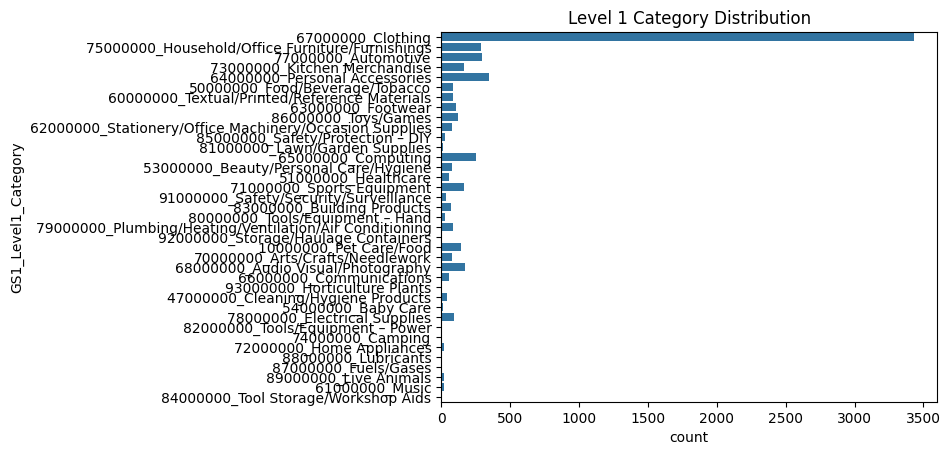

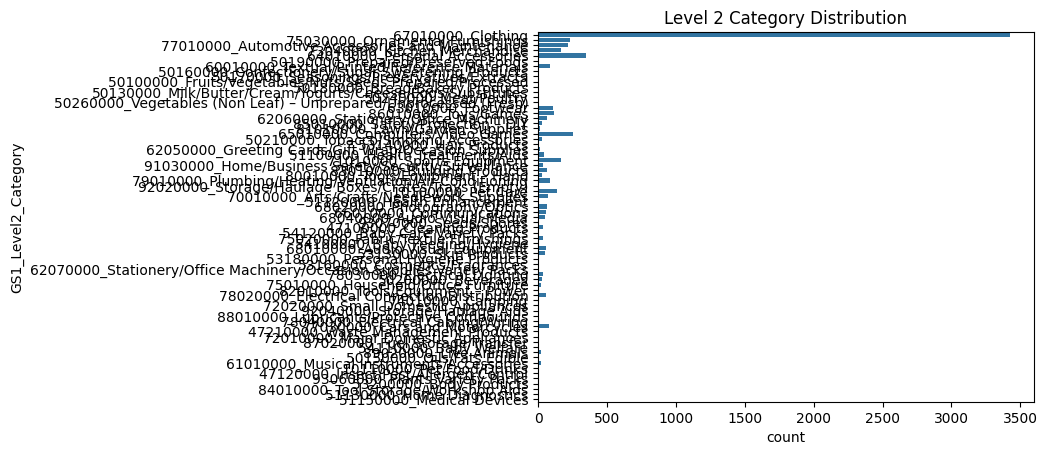

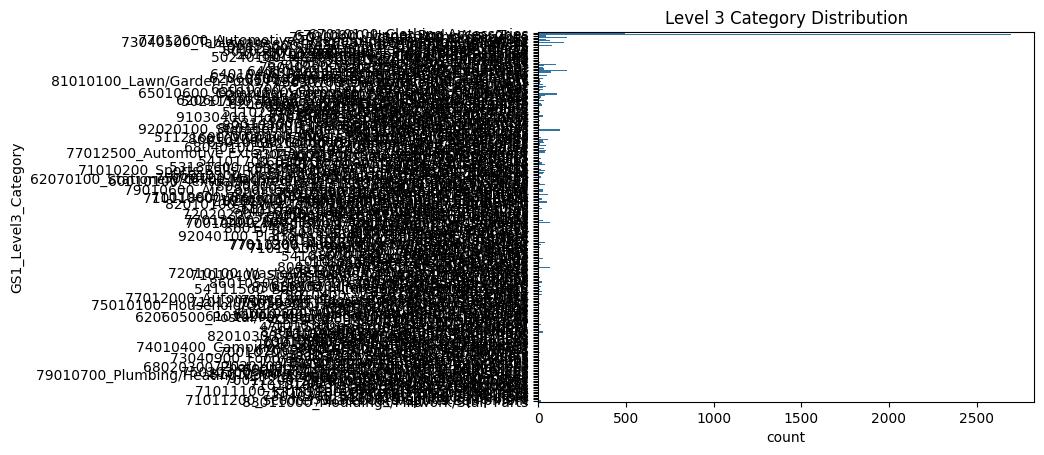

In [19]:
# Category distributions
sns.countplot(y="GS1_Level1_Category", data=product_df)
plt.title("Level 1 Category Distribution")
plt.show()

sns.countplot(y="GS1_Level2_Category", data=product_df)
plt.title("Level 2 Category Distribution")
plt.show()

sns.countplot(y="GS1_Level3_Category", data=product_df)
plt.title("Level 3 Category Distribution")
plt.show()

In [20]:
product_df["GS1_Level1_Category"].value_counts(normalize= True)*100

GS1_Level1_Category
67000000_Clothing                                         52.665540
64000000_Personal Accessories                              5.361807
77000000_Automotive                                        4.547550
75000000_Household/Office Furniture/Furnishings            4.440006
65000000_Computing                                         3.933016
68000000_Audio Visual/Photography                          2.642495
73000000_Kitchen Merchandise                               2.550315
71000000_Sports Equipment                                  2.519588
10000000_Pet Care/Food                                     2.212321
86000000_Toys/Games                                        1.828238
63000000_Footwear                                          1.705331
78000000_Electrical Supplies                               1.444154
50000000_Food/Beverage/Tobacco                             1.351974
60000000_Textual/Printed/Reference Materials               1.305884
79000000_Plumbing/Heating/Ve

In [41]:
product_df["GS1_Level1_Category"].value_counts()

GS1_Level1_Category
67000000_Clothing                                         3428
64000000_Personal Accessories                              349
77000000_Automotive                                        296
75000000_Household/Office Furniture/Furnishings            289
65000000_Computing                                         256
68000000_Audio Visual/Photography                          172
73000000_Kitchen Merchandise                               166
71000000_Sports Equipment                                  164
10000000_Pet Care/Food                                     144
86000000_Toys/Games                                        119
63000000_Footwear                                          111
78000000_Electrical Supplies                                94
50000000_Food/Beverage/Tobacco                              88
60000000_Textual/Printed/Reference Materials                85
79000000_Plumbing/Heating/Ventilation/Air Conditioning      84
62000000_Stationery/Office Machiner

In [56]:
counts = product_df["GS1_Level2_Category"].value_counts()

product_df["GS1_Level2_Category"][product_df["GS1_Level2_Category"].isin(counts[counts.isin([1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20])].index)].value_counts().sum()


191

In [55]:
counts = product_df["GS1_Level3_Category"].value_counts()

product_df["GS1_Level3_Category"][product_df["GS1_Level3_Category"].isin(counts[counts.isin([1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20])].index)].value_counts().sum()

847

Observation.
1. The data is highly imbalanced with 52.6% of the data belonging to single category "67000000_Clothing".

In [21]:
# Word count statistics
product_df["word_count"] = product_df["product"].apply(lambda x: len(x.split()))
product_df["word_count"].describe()

count    6509.000000
mean       86.663389
std       110.230650
min         4.000000
25%        51.000000
50%        70.000000
75%        92.000000
max      2674.000000
Name: word_count, dtype: float64

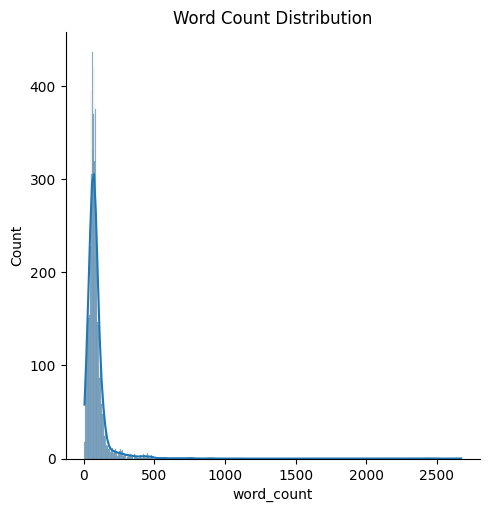

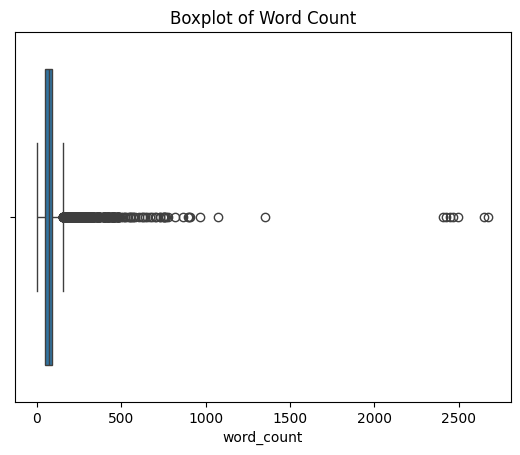

In [22]:
sns.displot(product_df["word_count"], kde=True)
plt.title("Word Count Distribution")
plt.show()

sns.boxplot(x=product_df["word_count"])
plt.title("Boxplot of Word Count")
plt.show()

Observation.
1. Data is right skewed.
2. Data has outliers.

In [23]:
# Character frequency analysis
text = " ".join(product_df["product"])
char_freq_df = pd.DataFrame(Counter(text).items(), columns=["character", "frequency"]).sort_values(by="frequency")
print(char_freq_df.tail(50))

   character  frequency
40         ?        611
37         9       2498
38         7       2836
34         8       2961
36         6       3369
32         q       3478
39                 3664
35         5       4584
20         4       4648
33         3       4858
30         z       5573
25         j       5632
28         !       6244
31         x       8178
17         2       8191
19         1       9178
18         0      11732
29         .      22056
7          v      25752
2          k      30791
15         w      45026
5          b      46750
27         y      52941
13         f      56989
26         g      59069
12         p      64549
24         m      67645
1          u      82431
0          d      95832
22         c      99137
14         h     109543
6          l     135644
21         n     162796
16         r     183341
8          i     189414
9          s     194243
11         o     205194
23         a     226465
10         t     229285
3          e     308299
4               

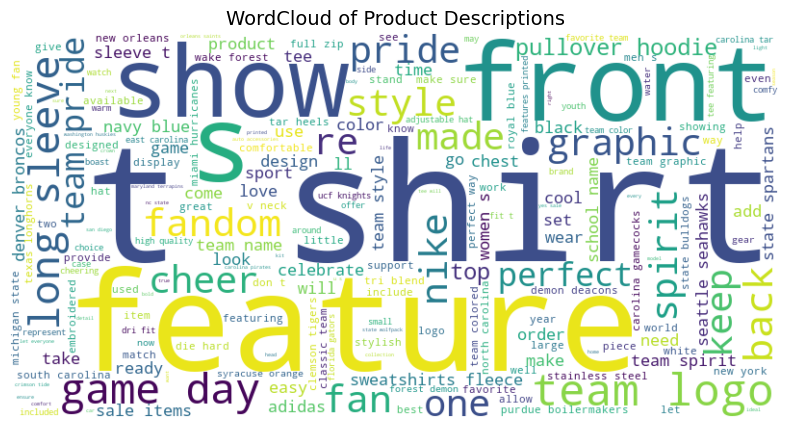

In [24]:
# wordcloud analysis

text = " ".join(product_df["product"])
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("WordCloud of Product Descriptions", fontsize=14)
plt.show()

FEATURE ENGINEERING

In [25]:
import numpy as np
import statsmodels.api as sm
from scipy import stats
from sklearn.preprocessing import StandardScaler

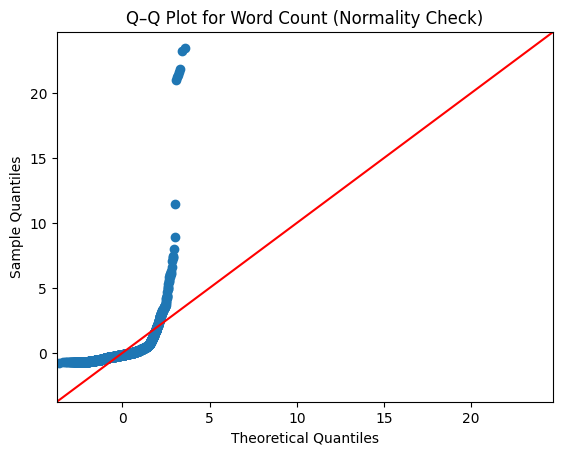

In [26]:
# --- Normality Check (Q-Q Plot) ---
fig = sm.qqplot(product_df["word_count"], line="45", fit=True)
plt.title("Q–Q Plot for Word Count (Normality Check)")
plt.xlabel("Theoretical Quantiles")
plt.ylabel("Sample Quantiles")
plt.show()

Observation.
1. The data is deviating from the red line, especially upper tail. Showing data is not normally distributed.

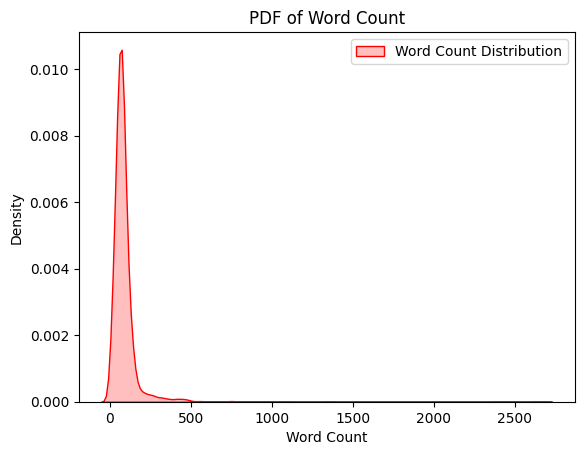

In [27]:
# --- Probability Density Function (PDF) ---
sns.kdeplot(product_df["word_count"].dropna(), fill=True, color="red", label="Word Count Distribution")
plt.title("PDF of Word Count")
plt.xlabel("Word Count")
plt.ylabel("Density")
plt.legend()
plt.show()

Observation.
1. The word count is not normally distributed.
2. The data is right skewed (long right tail).

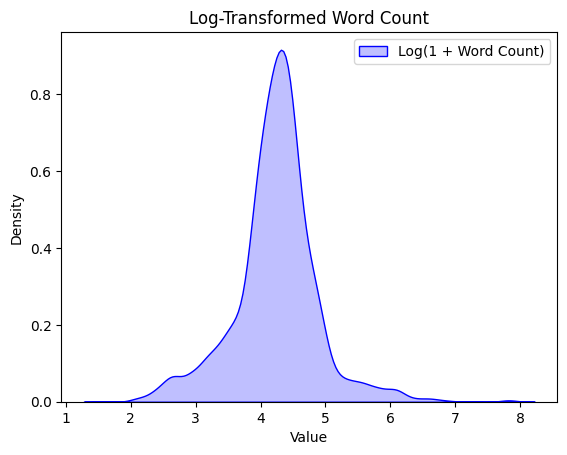

In [28]:
# --- Log Transformation ---
product_df["log_word_count"] = np.log1p(product_df["word_count"])

sns.kdeplot(product_df["log_word_count"], fill=True, color="blue", label="Log(1 + Word Count)")
plt.title("Log-Transformed Word Count")
plt.xlabel("Value")
plt.ylabel("Density")
plt.legend()
plt.show()

In [29]:
# --- Skewness Analysis ---
from scipy.stats import skew

skew_value = skew(product_df["word_count"].dropna())
log_skew_value = skew(product_df["log_word_count"].dropna())

print(f"Skewness (Word Count): {skew_value:.4f}")
print(f"Skewness (Log Word Count): {log_skew_value:.4f}")

Skewness (Word Count): 13.1970
Skewness (Log Word Count): 0.1387


Observation.
1. Log transform of the data is more of a normal distribution.
2. The word count is Log Normally Distributed.
3. Skewness statistic for log word count is close to zero (ideally between -0.5 and 0.5), confirming the symmetry.

In [30]:
# --- ANOVA Tests ---
for level in ["GS1_Level1_Category", "GS1_Level2_Category", "GS1_Level3_Category"]:
    data_groups = [product_df[product_df[level] == cat]["log_word_count"].dropna()
                   for cat in product_df[level].unique()]
    f_stat, p_val = stats.f_oneway(*data_groups)
    print(f"{level}: F-stat = {f_stat:.4f}, p-value = {p_val:.4f}")

GS1_Level1_Category: F-stat = 19.3502, p-value = 0.0000
GS1_Level2_Category: F-stat = 14.0846, p-value = 0.0000
GS1_Level3_Category: F-stat = 12.2488, p-value = 0.0000


Observation.
1. p value is less than 0.05.
2. Rejecting null hypothesis.
3. word count is important for prediction.

In [31]:
# --- Standardization ---
scaler = StandardScaler()
product_df["standard_log_word_count"] = scaler.fit_transform(product_df["log_word_count"].values.reshape(-1, 1))

print(product_df[["log_word_count", "standard_log_word_count"]].describe())

       log_word_count  standard_log_word_count
count     6509.000000             6.509000e+03
mean         4.232368             8.995041e-16
std          0.645356             1.000077e+00
min          1.609438            -4.064628e+00
25%          3.951244            -4.356453e-01
50%          4.262680             4.697219e-02
75%          4.532599             4.652535e-01
max          7.891705             5.670695e+00


Observation.
1. standard_log_word_count with mean of 0 and a standard deviation of 1.

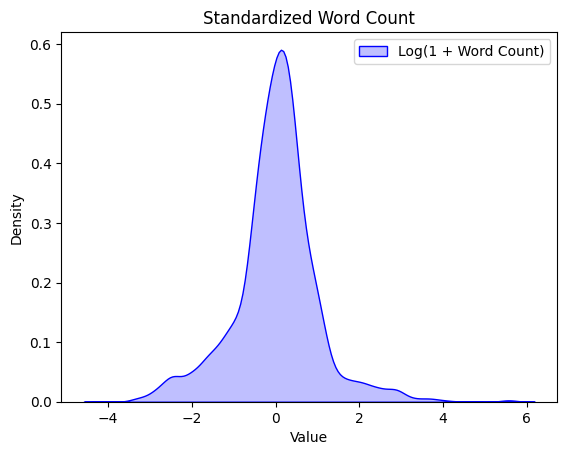

In [32]:
# --- Standardized Plot ---
sns.kdeplot(product_df["standard_log_word_count"], fill=True, color="blue", label="Log(1 + Word Count)")
plt.title("Standardized Word Count")
plt.xlabel("Value")
plt.ylabel("Density")
plt.legend()
plt.show()

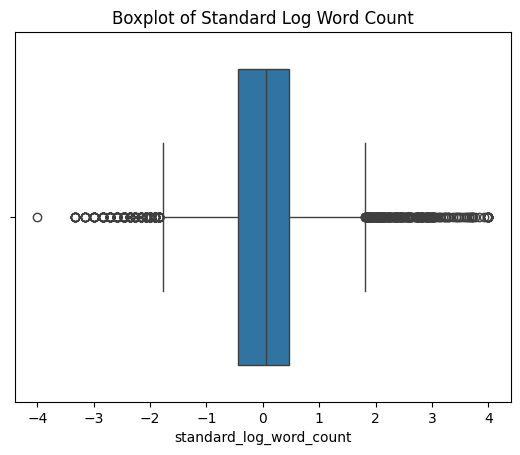

In [38]:
sns.boxplot(x=product_df["standard_log_word_count"])
plt.title("Boxplot of Standard Log Word Count")
plt.show()

In [ ]:
LOWER_CAP = -4.0
UPPER_CAP = 4.0

# Assume your DataFrame is named 'df' and the column is 'standard_log_word_count'
column_name = 'standard_log_word_count'

product_df[column_name] = np.where(
    product_df[column_name] < LOWER_CAP, 
    LOWER_CAP, 
    product_df[column_name]
)

product_df[column_name] = np.where(
    product_df[column_name] > UPPER_CAP, 
    UPPER_CAP, 
    product_df[column_name]
)

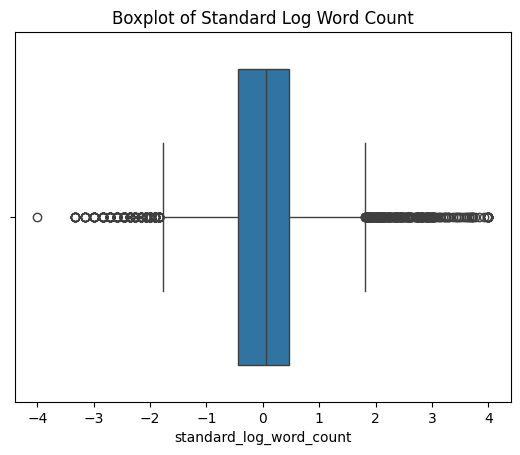

In [39]:
sns.boxplot(x=product_df["standard_log_word_count"])
plt.title("Boxplot of Standard Log Word Count")
plt.show()

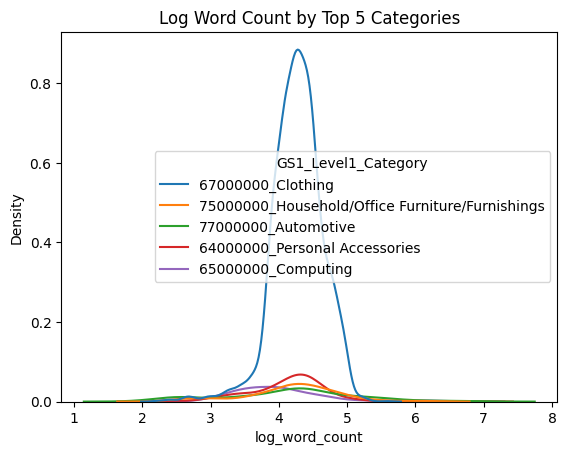

In [34]:
# --- Category-specific KDE plots ---
selected_cats = [
    "67000000_Clothing", "64000000_Personal Accessories", 
    "77000000_Automotive", "75000000_Household/Office Furniture/Furnishings",
    "65000000_Computing"
]

filtered_df = product_df[product_df["GS1_Level1_Category"].isin(selected_cats)]
sns.kdeplot(data=filtered_df, x="log_word_count", hue="GS1_Level1_Category")
plt.title("Log Word Count by Top 5 Categories")
plt.show()

C:\Users\suraj\AppData\Local\Temp\ipykernel_3996\3710790255.py:2: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(data=filtered_df, x="log_word_count", hue="GS1_Level1_Category",legend=False)


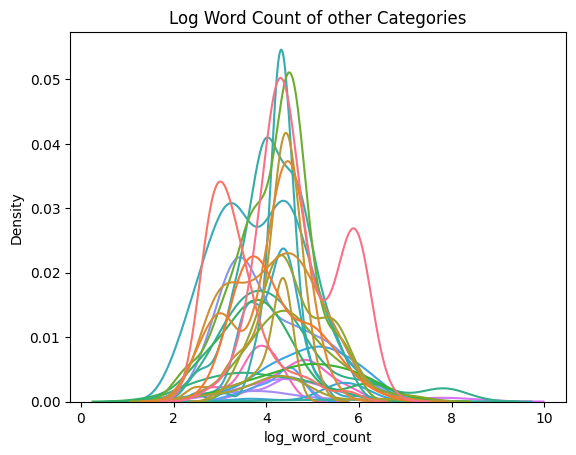

In [35]:
filtered_df = product_df[~product_df["GS1_Level1_Category"].isin(selected_cats)]
sns.kdeplot(data=filtered_df, x="log_word_count", hue="GS1_Level1_Category",legend=False)
plt.title("Log Word Count of other Categories")
plt.show()

Observation.
1. Most of the the log word count is normally distributed for each category.
2. word count dosent matter for a particular category.